# Fluid Dynamics of a Bent Pipe

<div>
<img src="https://raw.githubusercontent.com/illinois-mlp/MachineLearningForPhysics/main/img/Project_BentPipeSurrogate_splash.png" width=600>
</div>

## <span style="color:Orange">Overview</span>

Computational Fluid Dynamics (CFD) simulations are an essential but computationally expensive and time-consuming process. Surrogate modeling using machine learning can greatly speed up predictions by approximating the simulation results. In this notebook, we compare two surrogate approaches:
- A Fully Connected Feedforward Neural Network (FCFNN) baseline, treating each point independently.
- A Graph Neural Network (GNN) surrogate, leveraging the spatial mesh as a graph.

We will train these surrogates on ground truth CFD data (outputs: turbulent kinetic energy, pressure, velocity) for a bent-pipe flow, and compare their performance using residual analysis, we will also compare their runtime to see which fits best for real-time monitoring for the pipe.

By the end of this project hopefully you will be able to see the utility of surrogate models in fluid dynamics.

## <span style="color:Orange">Questions 1 & 2: Motivation for creating a surrogate model</span>

### <span style="color:LightGreen">Question 01: CFD runtime</span>

Why do traditional CFD simulations take so long to run? visit [Jose Alvarez and Mahmud Nobe's](https://colab.research.google.com/github/josealvarez97/The-Ultimate-Guide-to-Write-Your-First-CFD-Solver/blob/main/The_Ultimate_Guide_to_Write_Your_First_CFD_Solver.ipynb#scrollTo=fA1MTpR-FSmu) notebook to learn more about the math that goes behind the scenes when using a CFD simulation (hint: the infamous Navier–Stokes equation)

<font color=skyblue> **(Answer here)** </font>

Traditional CFD simulations are notoriously computationally expensive to run due to the scale and complexity of math involved to generate them. Specifically, producing accurate CFD simulations involves solving a set of complex coupled nonlinear partial differential equations (i.e. Navier-Stokes) with the according boundary conditions over fine grid meshes spanning potentially thousands to millions of cells. The equations in 3D, as outlined [here](https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/navier-strokes-equation/) by NASA, are explained below:
> Note: We have 4 independent variables $(x,y,z)$, our coordinates, and $t$ the time.

> There are also 6 dependent variables, the pressure $p$, density $\rho$, temperature $T$ (contained in the energy equation through the total energy $E_t$), and velocity components $(u,v,w)$.

 The Navier-Stokes equations themselves include:
 - A time-depedent continuity equation describing conservation of mass: $$\nabla \mathbf{u}=\frac{\partial \rho}{\partial t} + \frac{\partial (\rho u)}{\partial x}+ \frac{\partial (\rho v)}{\partial x} + \frac{\partial (\rho w)}{\partial y}-0$$
 - Three time-dependent equations describing conservation of momentum, taking the general form: $$\frac{\partial \mathbf{u}}{\partial t} + \mathbf{u}\cdot \nabla \mathbf{u} = - \frac{1}{\rho} \nabla p + \nu \nabla^2\mathbf{u}$$ or, more explicitly: $$\frac{\partial (\rho u)}{\partial t} + \frac{\partial (\rho u^2)}{\partial x}+ \frac{\partial (\rho uv)}{\partial y} + \frac{\partial (\rho uw)}{\partial z} = - \frac{\partial p}{\partial x} + \frac{1}{Re_r} \left( \frac{\partial \tau_{xx}}{\partial x} + \frac{\partial \tau_{xy}}{\partial y} + \frac{\partial \tau_{xz}}{\partial z} \right)$$
$$\frac{\partial (\rho v)}{\partial t} + \frac{\partial (\rho uv)}{\partial x}+ \frac{\partial (\rho v^2)}{\partial y} + \frac{\partial (\rho vw)}{\partial z} = - \frac{\partial p}{\partial y} + \frac{1}{Re_r} \left( \frac{\partial \tau_{xy}}{\partial x} + \frac{\partial \tau_{yy}}{\partial y} + \frac{\partial \tau_{yz}}{\partial z} \right)$$
$$\frac{\partial (\rho w)}{\partial t} + \frac{\partial (\rho uw)}{\partial x}+ \frac{\partial (\rho vw)}{\partial y} + \frac{\partial (\rho w^2)}{\partial z} = - \frac{\partial p}{\partial z} + \frac{1}{Re_r} \left( \frac{\partial \tau_{xz}}{\partial x} + \frac{\partial \tau_{yz}}{\partial y} + \frac{\partial \tau_{zz}}{\partial z} \right)$$
Where $Re$ is the Reynolds Number and the $\tau$ variables are components of the stress tensor.

 - And finally, a conservation of energy equation that is too long for me to type out in $\LaTeX\$ here. For its full form, see the NASA site linked above.



 These equations are generally not solvable analytically and computers require many iterations to closely approximate the expected result. The complex nature of solving these equations, the fine mesh grids required to represent proper fluid dynamic flows that necessitate finding such solutions for each point, and the necessity to iterate solutions to reach an accurate approximation culminate in CFD being a process requiring significant computational power/time. It also, however, makes the problem one especially well suited to machine learning applications, where such predictions can be made by an appropriately trained model that approximates solutions using its own pre-trained architecture rather than iteration at every point.

## <span style="color:Orange">Data structure from the CFD simulation</span>

Training a surrogate model requires a large amount of data in the desired range, which is why we will use the data from [this](https://www.nature.com/articles/s41529-025-00557-y) paper to train our model.

The system is a relatively simple bent pipe, structured as .txt files ranging from 0 to 200, with each file having a different velocity input towards the pipe. Each simulation file node data:

`([nodenumber ,    x-coordinate,     y-coordinate,     z-coordinate, turb-kinetic-energy,         pressure,      temperature, velocity-magnitude])`.

We drop the node index and filter out wall nodes (where velocity is zero) and we will ignore temperature. We then split into training and evaluation sets and compute normalization statistics.

In [2]:
!git clone https://github.com/lightiet/bended_pipe.git

Cloning into 'bended_pipe'...
remote: Enumerating objects: 219, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 219 (delta 0), reused 0 (delta 0), pack-reused 214 (from 2)
Receiving objects: 100% (219/219), 55.40 MiB | 25.83 MiB/s, done.
Resolving deltas: 100% (193/193), done.
Updating files: 100% (202/202), done.


### <span style="color:LightGreen">Question 02: the 3 quantities </span>
Why is it important to monitor these 3 quantities in a system of interest? as a reminder they are

- Turbulent Kinetic Energy (TKE)

- pressure

- velocity

<font color=skyblue> **(Answer here)** </font>

The three quantities outlined below are crucial to understand fluid dynamics in a system of interest:
- **Turbulent Kinetic Energy (TKE):** TKE quantifies the mean kinetic energy per unit mass associated with eddies (swirls of fluids and reverse currents) in turbulent flow. Put more simply, TKE is important because it describes the intensity of velocity fluctuations in a turbulent flow (i.e. how "turbulent" the flow really is). Thus, a higher TKE corresponds to larger deviations and a more chaotic flow. It is given by the half sum of the variances of the velocity components: $$k = \frac{1}{2} \left( \sigma_u^2 + \sigma_v^2 + \sigma_w^2\right) = \frac{1}{2} \left( \overline{(u')^2} + \overline{(v')^2} + \overline{(w')^2} \right) $$
- **Pressure:** A measure of normal force per unit area exerted by the fluid, pressure is described as a field over our system. Variations in the pressure field is what ultimately drives the flow of fluid. To maximize entropy, fluid in high pressure equilibriates by moving towards areas of lower pressure. Knowing the pressure is therefore essential to solving the Navier-Stokes equations to understand and predict the changes in flow.
- **Velocity:** The field of velocity vectors of the fluid at grid points in our system is one of the required quantities in the Navier-Stokes equations, and describes the direction and magnitude of fluid flow, driven by variations in pressure. Monitoring the fluid velocity helps us understand the current flow and, in conjunction with the pressure field, predict how the flow will evolve over time. It can also set boundary conditions for solving the Navier-Stokes equations, such as the "no-slip condition", which requires $\vec{v}=0$ at points along the pipe wall.

## <span style="color:Orange">Data preparation</span>

In [3]:
!pip install -q torch-geometric
import time
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, knn_graph
from torch_geometric.utils import to_undirected
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
torch.manual_seed(42)
np.random.seed(42)
rng = np.random.default_rng(seed=42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.1 MB/s eta 0:00:00


In [4]:
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.10.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 8.9 MB/s eta 0:00:00


### <span style="color:LightGreen">Question 03: Data preprocessing</span>

Prepare the data for training.

think about the desired goal of this project, what should be the shape of the input and output vectors?

In [5]:
data_dir     = "bended_pipe/test_output_data"
file_pattern = "axial_output_{}.txt"
start_index  = 0
end_index    = 200  #
num_sims = end_index - start_index + 1
nodes_per_sim = 11340

# 1) Fill in the correct shape: (num_sims, nodes_per_sim, number_of_features)
#    Features here are: x, y, z, TKE, pressure, velocity
# YOUR CODE HERE
number_of_features = 6
data_tensor = np.empty((num_sims, nodes_per_sim, number_of_features), dtype=np.float32)

for sim_idx, i in enumerate(range(start_index, end_index + 1)):
    fn  = os.path.join(data_dir, file_pattern.format(i))
    raw = np.loadtxt(fn, skiprows=1)           # shape (11340, 8)
    raw = raw[raw[:, 0].argsort()]              # sort by node number

    # 2) Select the correct columns for [x, y, z, TKE, pressure, velocity]:
    #    Remember: raw has columns [node#, x, y, z, TKE, pressure, temp, velocity]
    # YOUR CODE HERE
    data_tensor[sim_idx] = raw[:,[1,2,3,4,5,7]] # excludes node # and temp

# 3) Build a mask that drops any node where velocity (last feature) == 0:
# YOUR CODE HERE
mask = data_tensor[0, :, 5] != 0
data_tensor = data_tensor[:, mask, :]
print("data_sorted!")

data_sorted!


In [6]:
#segregate data to training and eval
perm      = rng.permutation(num_sims)
split_pt  = int(0.2 * num_sims)
eval_idx  = perm[:split_pt]
train_idx = perm[split_pt:]

train_tensor = data_tensor[train_idx]
eval_tensor  = data_tensor[eval_idx]

In [7]:
print("shape of the training tensor is" , train_tensor.shape)
print("shape of the evaluation tensor is" , eval_tensor.shape)

shape of the training tensor is (161, 11016, 6)
shape of the evaluation tensor is (40, 11016, 6)


### <span style="color:LightGreen">Reynolds Number (Re)</span>

The equation for Reynolds number is

$$ \Large
Re = \frac{\rho U D}{\mu}
$$

- ρ is the density of the water
- U is the flow velocity (usually taken at the inlet)
- D is the diameter of the opening which is 0.025 m in our case
- μ is the dynamic viscosity of the water.

This equation is especially important in fluid dynamics since it characterizes the regime of the system, when Re is high that means that the system is more turbulent and chaotic, and when Re is low the system is laminar and predictable.

In [8]:
def reynolds(U):
    return 87500 * U #in our case we only have one variable in the equation, U, the constants turn out to be 87500 after simplification

### <span style="color:LightGreen">Question 04: Predictability and Re</span>

based on what you just read, what do you think the relationship between our surrogate model's accuracy and Re will be?

<font color=skyblue>**(Answer here)**</font>

Re is given to be directly proportional to U, the flow velocity at the inlet. I predict that at higher Re (thus higher U), the surrogate model's accuracy will decrease. At high U, the velocity of flow at the inlet is high and thus we see the flow will be more chaotic and turbulent, likely making it less predictable by our model due to the sharper/more severe deviations in the flow. The model will likely have issues making predictions for data with steep gradients and rapidly changing flows, leading to more significant error.

### <span style="color:LightGreen">Visualizing understanding the data</span>
The following is a code snippet to visualize the data and help you gain intuition of what the data looks like

In [9]:
#mini helper function
def get_inlet_vel(sim_idx: int):
   return (data_tensor[sim_idx, 2, 5]) #3rd node's velocity is the inlet velocity

In [10]:
# 1) extract the velocity arrays for each simulation
velocities = data_tensor[:, :, 5]  # shape: (201, N_nodes)

# 2) compute per‐simulation statistics
max_vels = np.max(velocities, axis=1)  # highest velocity in each sim
min_vels = np.min(velocities, axis=1)  # lowest velocity in each sim

# 3) find the best (lowest max), worst (highest max), and the median‐case sim
best_idx   = np.argmin(max_vels)
worst_idx  = np.argmax(max_vels)

# for the median‐case, sort by max_vel and pick the middle simulation
sorted_by_max = np.argsort(max_vels)
median_idx    = sorted_by_max[len(sorted_by_max) // 2]

# collect indices for plotting
sim_indices = np.array([best_idx, median_idx, worst_idx])


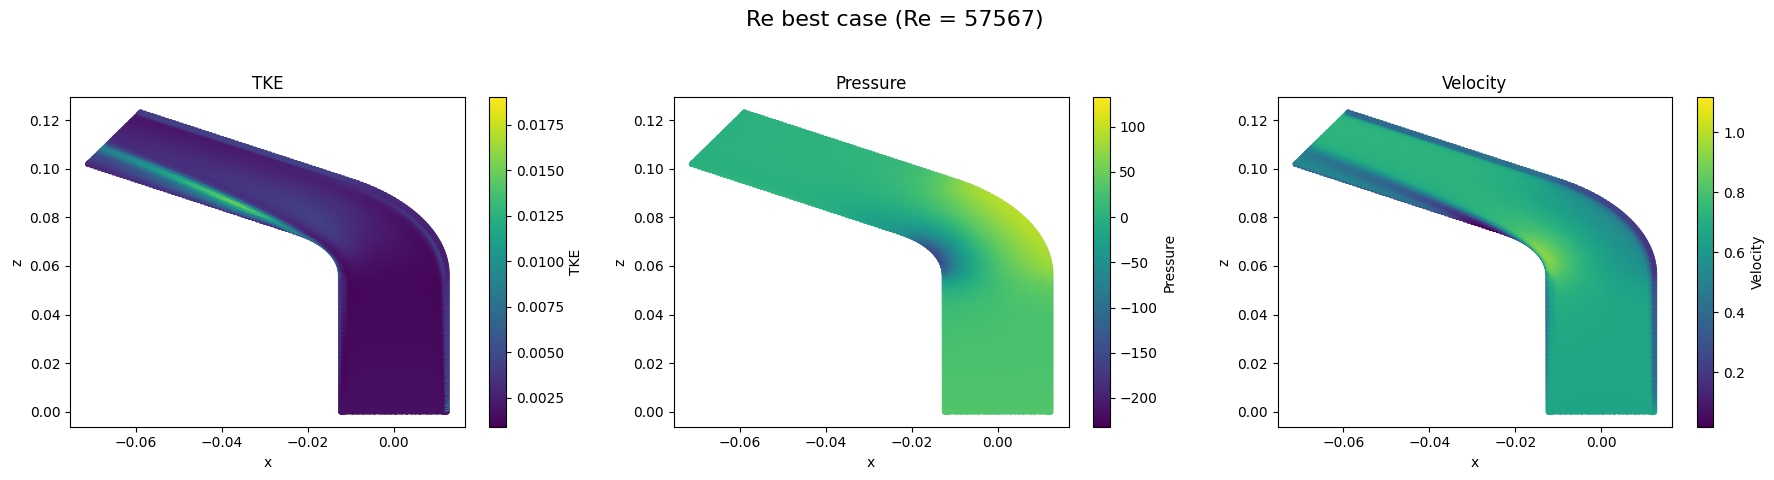

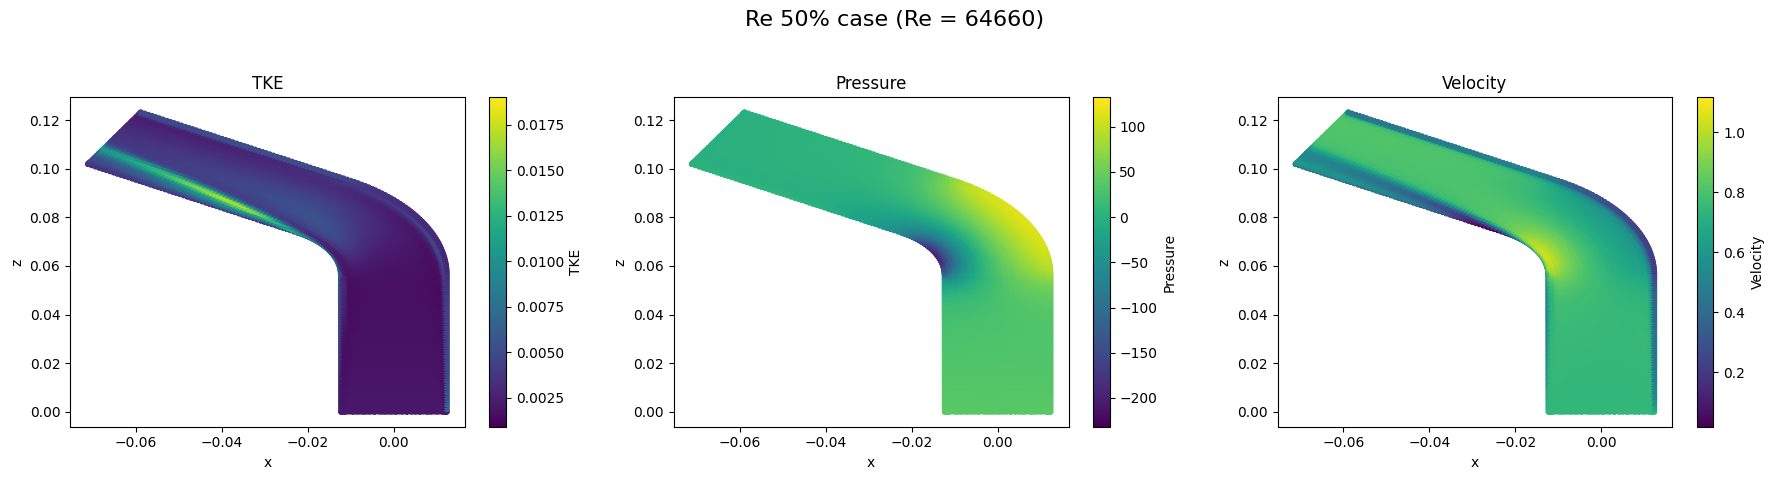

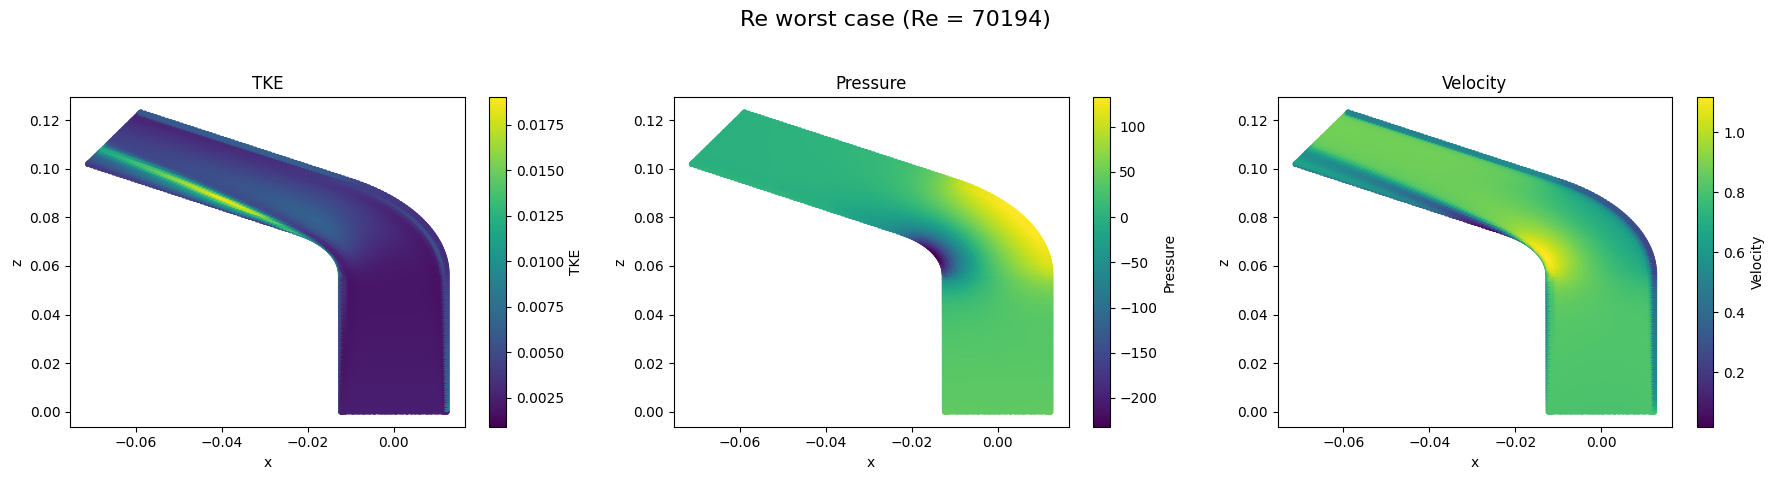

In [11]:
var_names   = ['TKE', 'Pressure', 'Velocity']
case_labels = ['Re best case', 'Re 50% case', 'Re worst case']

vmins, vmaxs = [], []
for idx in range(len(var_names)):
    vals = data_tensor[sim_indices, :, 3 + idx]
    vmins.append(vals.min())
    vmaxs.append(vals.max())

for sim, label in zip(sim_indices, case_labels):
    # get inlet velocity and compute Reynolds number
    inlet_vel = get_inlet_vel(sim)
    Re_number = reynolds(inlet_vel)

    x = data_tensor[sim, :, 0]
    z = data_tensor[sim, :, 2]

    fig, axs = plt.subplots(1, len(var_names), figsize=(18, 5))
    for idx, name in enumerate(var_names):
        ax = axs[idx]
        values = data_tensor[sim, :, 3 + idx]
        sc = ax.scatter(
            x, z, c=values, s=10,
            vmin=vmins[idx], vmax=vmaxs[idx]
        )
        fig.colorbar(sc, ax=ax, label=name)
        ax.set_title(f"{name}")
        ax.set_xlabel("x")
        ax.set_ylabel("z")

    fig.suptitle(f"{label} (Re = {Re_number:.0f})", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


## <span style="color:Orange">Real-time monitoring  of the pipe by ML</span>

Now that we've established that CFD models require significant computational resources, naturally they are not suitable for real-time prediction of a system's state. This is where machine learning becomes valuable: by training models specifically on the geometry and outputs of our system, we can achieve accurate, real-time predictions.

Two approaches are presented below—try both and compare their performance.










### <span style="color:LightGreen">Question 05: Fully Connected Feedforward Neural Network (FCFNN) approach</span>
let's try the simplest method we have at our disposal, a FCFNN.
Build an FCFNN that takes in the `[x,y,z,U]` and spits out `[TKE, Pressure, Velocity]`

To begin, we’ll load the data into a tensor and normalize it to prepare it for training.

In [12]:
coords_train = train_tensor[:,:,0:3].reshape(-1,3)
inlet_flat   = train_tensor[:,2,5].reshape(-1,1)  # velocity at node 2
Xcat = np.hstack([ np.repeat(coords_train, 1, axis=0),
                   np.repeat(inlet_flat, coords_train.shape[0]//inlet_flat.shape[0], axis=0) ])
Y_flat = train_tensor[:,:,3:6].reshape(-1,3)

mu_in,  s_in  = Xcat.mean(axis=0), Xcat.std(axis=0)  + 1e-8
mu_out, s_out = Y_flat.mean(axis=0), Y_flat.std(axis=0) + 1e-8

norm_stats = (
    torch.tensor(mu_in,  dtype=torch.float32),
    torch.tensor(s_in,   dtype=torch.float32),
    torch.tensor(mu_out, dtype=torch.float32),
    torch.tensor(s_out,  dtype=torch.float32)
)

Now we have
- `mu_in, s_in`

which are the per‑feature mean and standard deviation of inputs [x, y, z, U]
- `mu_out, s_out`

 which are  the per‑feature mean and standard deviation of targets [TKE, Pressure, Velocity].

In [13]:
# Use the standard Linear and ReLU layers for fully connected networks
# 4 input dims (x,y,z,U), 3 output dims (TKE, p, v), 3 layers of dim hidden_dim
class FCFNN(nn.Module):
    # YOUR CODE HERE
    def __init__(self, input_dim=4, output_dim=3, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,3)
        )

    def forward(self, x):
        return self.net(x)

In [14]:
mu_in_t, s_in_t, mu_out_t, s_out_t = norm_stats
coords_train_np = train_tensor[:, :, 0:3].reshape(-1, 3)
N_train_nodes   = coords_train_np.shape[0]
num_train_sims  = train_tensor.shape[0]
nodes_per_train = train_tensor.shape[1]

inlet_repeated = np.repeat(
    train_tensor[:, 2, 5].reshape(-1, 1),   # (num_train_sims, 1)
    nodes_per_train, axis=0
)
X_raw = np.hstack([coords_train_np, inlet_repeated]).astype(np.float32)
Y_raw = train_tensor[:, :, 3:6].reshape(-1, 3).astype(np.float32)

X_norm = (X_raw - mu_in_t.numpy())  / s_in_t.numpy()
Y_norm = (Y_raw - mu_out_t.numpy()) / s_out_t.numpy()

X_tr = torch.from_numpy(X_norm).float()
Y_tr = torch.from_numpy(Y_norm).float()

fcfnn_model = FCFNN(input_dim=4, hidden_dim=256, output_dim=3).to(device)
fcfnn_optimizer = torch.optim.Adam(fcfnn_model.parameters(), lr=1e-3)
fcfnn_criterion = nn.MSELoss()

fcfnn_dataset = torch.utils.data.TensorDataset(X_tr, Y_tr)
fcfnn_loader  = DataLoader(fcfnn_dataset, batch_size=4096, shuffle=True)

print("Training FCFNN...")
for epoch in range(1, 21):
    fcfnn_model.train()
    epoch_loss = 0.0
    for xb, yb in fcfnn_loader:
        xb, yb = xb.to(device), yb.to(device)
        fcfnn_optimizer.zero_grad()
        pred = fcfnn_model(xb)
        loss = fcfnn_criterion(pred, yb)
        loss.backward()
        fcfnn_optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(fcfnn_dataset)
    if epoch % 5 == 0:
        print(f"  FCFNN Epoch {epoch:3d} | Loss: {epoch_loss:.6f}")

# Save checkpoint with norm stats
torch.save({
    'model_state_dict': fcfnn_model.state_dict(),
    'norm_stats': norm_stats,
}, 'fcfnn_checkpoint.pt')
print("FCFNN saved to fcfnn_checkpoint.pt")

Training FCFNN...
  FCFNN Epoch   5 | Loss: 0.016763
  FCFNN Epoch  10 | Loss: 0.010079
  FCFNN Epoch  15 | Loss: 0.008078
  FCFNN Epoch  20 | Loss: 0.007536
FCFNN saved to fcfnn_checkpoint.pt


In [15]:

model = FCFNN()
torch.save(model.state_dict(), 'fcfnn_checkpoint.pth')

### <span style="color:LightGreen">Question 06: Graph neural networks</span>
Treat each mesh point in the CFD simulation as a node whose behavior is influenced by its neighbors, and capture these local interactions with a graph neural network. Construct a GNN that first builds a K‑nearest‑neighbor graph based on the 3D coordinates, then processes the normalized input features`[x,y,z,U]` through an encoder, several graph‑convolution layers, and a decoder to predict the three target fields `[TKE, Pressure, Velocity]` just like the FCFNN.

Be sure to standardize both inputs and outputs before training.

In [16]:
SEED = 42
hidden_dim     = 128
num_layers     = 3
learning_rate  = 1e-3
epochs          = 15
batch_size      = 1
k_neighbors     = 6      # for KNN graph

In [17]:
# Use the included torch.geometric.nn
def build_knn_graph(coords, k):
    """
    Given coords of shape (N,3), build a 2xE edge_index tensor
    connecting each node to its k nearest neighbors (excluding itself).
    Returns: torch.LongTensor edge_index
    """
    # initially intended to use the included import knn_graph, ran into an
    # import issue for tensor-clusters where it took forever to download
    # return knn_graph(coords, k=k, loop=False)
    # the replacement method was written using the also included import
    # NearestNeighbors and additionally informed with LLM assistance
    nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='auto').fit(coords)
    _, indices = nbrs.kneighbors(coords)  # (N, k+1) — first column is self

    rows = np.repeat(np.arange(len(coords)), k)
    cols = indices[:, 1:].flatten()

    edge_index = torch.tensor(np.vstack([rows, cols]), dtype=torch.long)
    edge_index = to_undirected(edge_index)
    return edge_index



In [18]:
class FlowDataset(Dataset):
    def __init__(self, data_tensor, mask=None, norm_stats=None):
        self.data = data_tensor
        self.mask = mask
        self.mu_in, self.s_in, self.mu_out, self.s_out = norm_stats
        # coords identical for every sim
        self.coords = torch.tensor(data_tensor[0,:,:3], dtype=torch.float32)
        self.edge_index = build_knn_graph(self.coords.numpy(), k_neighbors)
    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        arr = self.data[idx] # describes a simulation's worth of node data
        # 2) Extract xyz positions and inlet velocity and normalize inputs (x) and outputs (y)
        coords_xyz = arr[:,:3] # for each node extracts the x,y,z coords
        N = len(coords_xyz) # number of nodes
        inlet_v = arr[2,5] # inlet_flat describes the inlet velocity and uses Node 2, so we also use it
        u_arr = np.array([inlet_v] * N).reshape((N,1)) # column of the inlet velocity for this sim

        x_raw = np.hstack([coords_xyz, u_arr])
        y_raw = torch.from_numpy(arr[:,3:6])

        # standardize raw outputs before returning
        x = (torch.from_numpy(x_raw) - self.mu_in) / self.s_in
        y = (y_raw - self.mu_out) / self.s_out

        return x, y, self.edge_index

def collate_graph(batch):
    return batch[0]

In [19]:
class GraphConvLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # Initialize linear layers for self‑ and neighbor contributions
        # YOUR CODE HERE
        self.lin_self = nn.Linear(dim,dim)
        self.lin_neighbors = nn.Linear(dim,dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, h, edge_index): # based off message_passing_step from HW7
        #implement message passing
        # YOUR CODE HERE
        N = len(h)
        src, dst = edge_index[0], edge_index[1]

        sum = torch.zeros_like(h)
        sum.index_add_(0, dst, h[src])

        deg = torch.zeros(h.size(0), 1, device=h.device)
        deg.index_add_(0, dst, torch.ones(src.size(0), 1, device=h.device))
        deg = deg.clamp(min=1)

        nbhd_mean = sum / deg

        out = F.relu(self.norm(self.lin_self(h) + self.lin_neighbors(nbhd_mean)))
        return out


class FlowGNN(nn.Module):
    def __init__(self, in_dim=4, hidden_dim=128, out_dim=3, n_layers=3):
        super().__init__()
        # 1) Define an encoder to map input features to hidden_dim
        # 2) Create a sequence of GraphConvLayer modules
        # 3) Define a decoder to map back to output dimension

        # YOUR CODE HERE
        self.encoder = nn.Sequential( # 1) encoder
            nn.Linear(in_dim,hidden_dim),
            nn.ReLU()
        )

        self.conv_layers = nn.ModuleList( # 2) create n_layers of GraphConvLayer
            [GraphConvLayer(hidden_dim) for _ in range(n_layers)]
        )

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, out_dim)
        )


    def forward(self, x, edge_index):
        # implement GNN forward
        # YOUR CODE HERE
        h = self.encoder(x)
        for conv in self.conv_layers:
          h = conv(h,edge_index)
        return self.decoder(h)

Now create a training loop

In [20]:
import random

In [21]:
train_set = FlowDataset(train_tensor, mask, norm_stats)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
model = FlowGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

train_data = []
for idx in range(len(train_set)):
    x, y, edge_index = train_set[idx]
    train_data.append((x.to(device), y.to(device), edge_index.to(device)))

for epoch in range(1, epochs + 1):
    model.train()
    random.shuffle(train_data)
    epoch_loss = 0.0
    for x, y, edge_index in train_data:
        optimizer.zero_grad()
        loss = criterion(model(x, edge_index), y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if epoch % 3 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{epochs} | Loss: {epoch_loss/len(train_data):.6f}")


torch.save({'model_state_dict': model.state_dict(), 'norm_stats': norm_stats,}, 'gnn_checkpoint.pt')

  Epoch   1/15 | Loss: 0.351509
  Epoch   3/15 | Loss: 0.160881
  Epoch   6/15 | Loss: 0.118738
  Epoch   9/15 | Loss: 0.086590
  Epoch  12/15 | Loss: 0.085627
  Epoch  15/15 | Loss: 0.063190


### <span style="color:LightGreen">Question 07: Visualizing the output of the models</span>
Implement a function `predict_fields(U)` that, given an inlet velocity `U` and model `GNN` or `FCFNN`, computes and returns the model’s predicted field values across the entire pipe.

In [22]:
def predict_fields(U: float, model_type: str) -> np.ndarray:
    """
    Given inlet velocity U, returns an (N, 6) array:
    [x, y, z, TKE_pred, pressure_pred, velocity_pred]
    """
    if model_type.upper() == "GNN":
        ckpt = torch.load("gnn_checkpoint.pt", map_location=device)
        model = FlowGNN(in_dim=4, hidden_dim=hidden_dim, out_dim=3, n_layers=num_layers)
    elif model_type.upper() == "FCFNN":
        ckpt = torch.load("fcfnn_checkpoint.pt", map_location=device)
        model = FCFNN(input_dim=4, hidden_dim=(256), output_dim=3) #you might want to change these values to match your model
    else:
        raise ValueError(f"Unsupported model_type: {model_type}")

    model.load_state_dict(ckpt['model_state_dict'])
    model.to(device).eval()
    mu_in, s_in, mu_out, s_out = ckpt['norm_stats']

    coords_np  = data_tensor[0, :, :3].astype(np.float32)
    edge_index = build_knn_graph(coords_np, k_neighbors).to(device)

    N = coords_np.shape[0]
    U_col = np.full((N, 1), U, dtype=np.float32)
    X_raw = np.hstack([coords_np, U_col])
    X_norm = (X_raw - mu_in.cpu().numpy()) / s_in.cpu().numpy()

    x_t = torch.from_numpy(X_norm).float().to(device)

    with torch.no_grad():
        if model_type.upper() == "GNN":
            out_norm = model(x_t, edge_index)
        else:
            out_norm = model(x_t)

    # De-normalize outputs
    Y_pred = (out_norm.cpu().numpy() * s_out.cpu().numpy()) + mu_out.cpu().numpy()

    # Return stacked coords + predictions
    return np.hstack([coords_np, Y_pred])

Now we are ready! with the simple call of a function and an input of inlet velocity, we can get the profile for the whole pipe.

Now let's test the run time and plot an example.

### <span style="color:LightGreen">Question 08: Evaluation of the models </span>


GNN predict_fields took 0.192548 seconds
FCFNN predict_fields took 0.118389 seconds


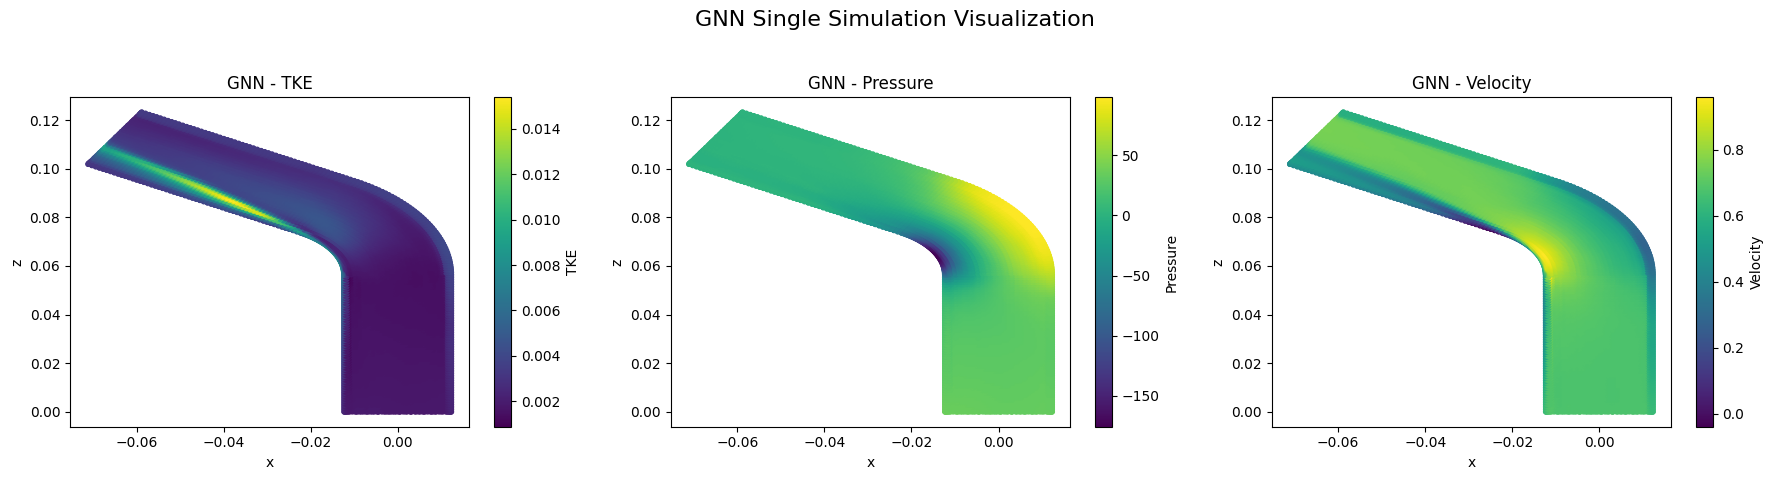

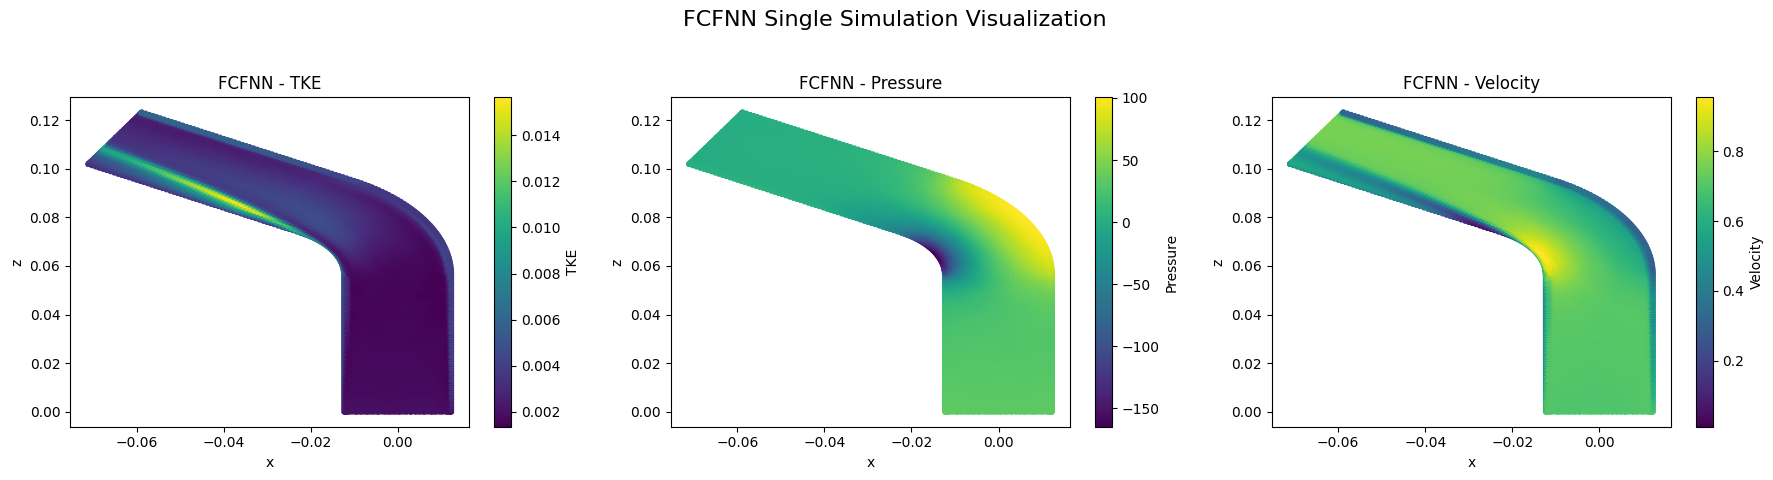

In [23]:
# Time GNN prediction
start = time.perf_counter()
gnn_output = predict_fields(0.69, "GNN")
end = time.perf_counter()
print(f"GNN predict_fields took {end - start:.6f} seconds")

# Time FCFNN prediction
start = time.perf_counter()
fcfnn_output = predict_fields(0.69, "FCFNN")
end = time.perf_counter()
print(f"FCFNN predict_fields took {end - start:.6f} seconds")

# plot outputs
var_names = ['TKE', 'Pressure', 'Velocity']
model_outputs = [gnn_output, fcfnn_output]
model_labels = ['GNN', 'FCFNN']

for model_out, model_label in zip(model_outputs, model_labels):
    x = model_out[:, 0]
    z = model_out[:, 2]

    fig, axs = plt.subplots(1, len(var_names), figsize=(18, 5))
    for idx, name in enumerate(var_names):
        ax = axs[idx]
        values = model_out[:, 3 + idx]
        sc = ax.scatter(x, z, c=values, s=10)
        fig.colorbar(sc, ax=ax, label=name)
        ax.set_title(f"{model_label} - {name}")
        ax.set_xlabel("x")
        ax.set_ylabel("z")

    fig.suptitle(f"{model_label} Single Simulation Visualization", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

As you can see this is quite powerful, we no longer need to compute the profile of the pipe using CFD anymore, we can just call the predict_fields function and we will get what we need in an instant!

now before we use this model to monitor our pipe, we should check for validity, the code below shows the loss in each of the 4 outputs.

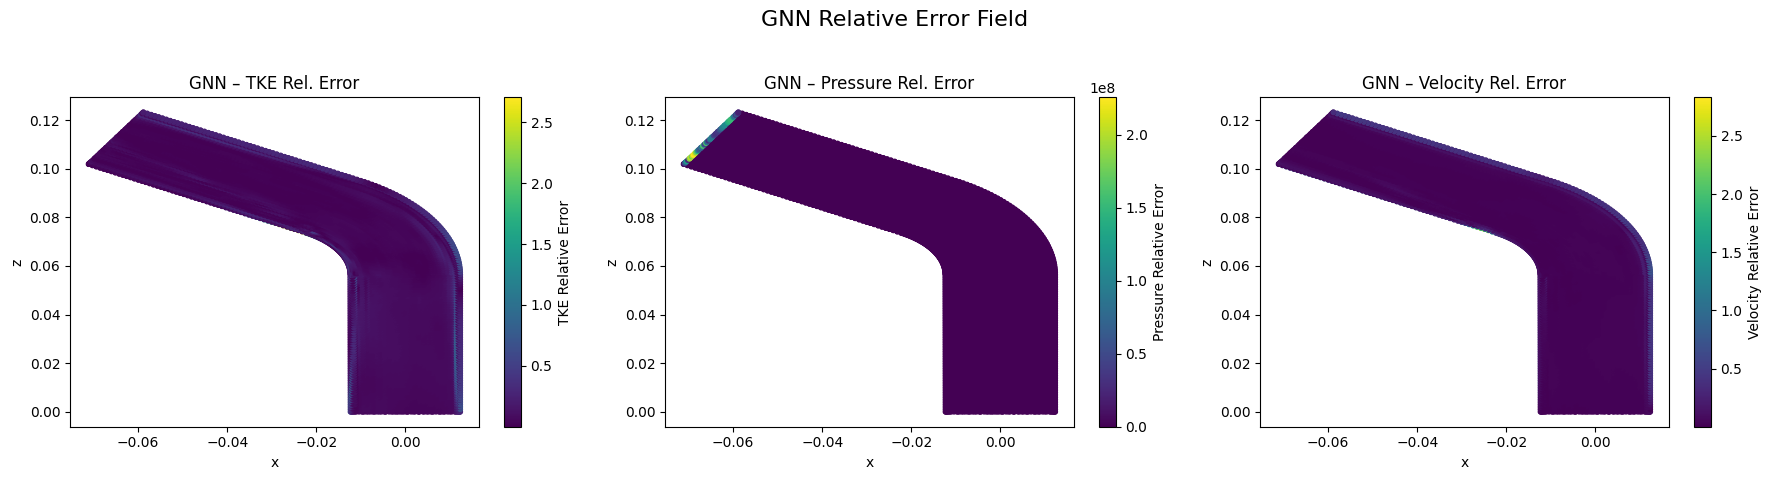

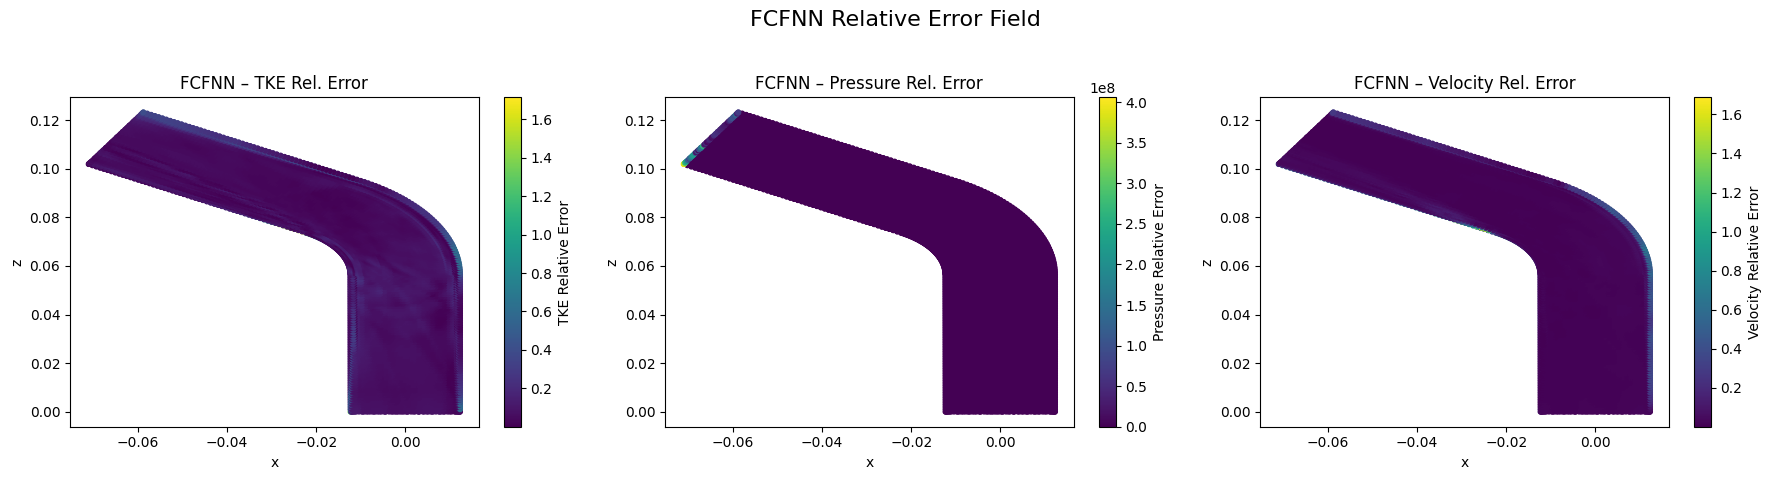

In [24]:
sim   = 0
U_val = 0.69
ε     = 1e-8 #to avoid accidental division by 0
coords_np = data_tensor[0, :, :3].astype(np.float32)

# Ground truth
actual    = data_tensor[sim, :, 3:6]

# Predictions
gnn_pred    = predict_fields(U_val, "GNN")[:, 3:6]
fcfnn_pred  = predict_fields(U_val, "FCFNN")[:, 3:6]

# Compute relative errors: |pred - true| / (|true| + ε)
gnn_rel_err   = np.abs(gnn_pred   - actual) / (np.abs(actual) + ε)
fcfnn_rel_err = np.abs(fcfnn_pred - actual) / (np.abs(actual) + ε)

for rel_err, label in [(gnn_rel_err, "GNN"), (fcfnn_rel_err, "FCFNN")]:
    x = coords_np[:, 0]
    z = coords_np[:, 2]

    fig, axs = plt.subplots(1, len(var_names), figsize=(18, 5))
    for idx, name in enumerate(var_names):
        ax = axs[idx]
        sc = ax.scatter(
            x, z,
            c=rel_err[:, idx],
            s=10,
            cmap='viridis'
        )
        fig.colorbar(sc, ax=ax, label=f"{name} Relative Error")
        ax.set_title(f"{label} – {name} Rel. Error")
        ax.set_xlabel("x")
        ax.set_ylabel("z")

    fig.suptitle(f"{label} Relative Error Field", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

From the results above, which NN works best for this use case?

<font color=skyblue>**(Answer here)**</font>

From the results above, I would argue the **GNN** works best for this use case over the FCFNN, though each has its strengths and weaknesses.
- For the similarities, both demonstrate very strong performance (high accuracy) in the interior of the pipe, with most of the prediction error focused around either the walls of the pipe or the outlet of the pipe.
- **TKE:** The GNN appears to perform much better with regards to the TKE error, where we only observe some slight deviations from the simulation around the edges of the pipe. The error of the FCFNN spans a much larger area, however, with noticeable deviations throughout the entire bottom half of the pipe.
- **Pressure:** Both models achieve very high accuracy throughout the entire interior and walls of the pipe, with the exception being that they struggle with nailing the pressure at the upper-left end of the pipe, where the error is noticeably severe. In this case, the FCFNN has a lower maximum error (\~3.5e8) compared to the GNN (~5.5e8). It's notable how severe the error is, being of order 1e8.
- **FCFNN:** Both again perform very well in the interior and have their error largely clustered on the outer (upper-right) wall and around the bend in the pipe, for which the GNN shows a higher maximum error (\~1.75) compared to the FCFNN (~1.25)

**Conclusion:** While it is true that the FCFNN appears to show lower relative error clustered around the same areas as the GNN in the pressure and velocity measures, I would argue its large, noticeable, *non-localized* error visible in its predictions for the TKE justify choosing the GNN over it.

<font color='lightgreen'>**NOTE:** The above was written for a previous run of the data, and I had to re-run the notebook when I came back to it later due to a time-out, resulting in slightly different plots. In the original, the TKE error was much more pronounced for the FCFNN model, but it still remains somewhat visibly nonlocal, with significant discrepancies spanning the entire bottom half of the pipe.</font>

### <span style="color:LightGreen">Question 09: Relationship between Re and loss </span>
Write a breif scrip that plots Re vs model loss for both models over the evaluation simulations.

In [28]:
data_tensor[0,2]

array([-1.2142798e-02, -1.6500000e-03,  0.0000000e+00,  1.7593977e-03,
        3.7127357e+01,  6.8496180e-01], dtype=float32)

Evaluating models over evaluation set...
  5/40 done
  10/40 done
  15/40 done
  20/40 done
  25/40 done
  30/40 done
  35/40 done
  40/40 done


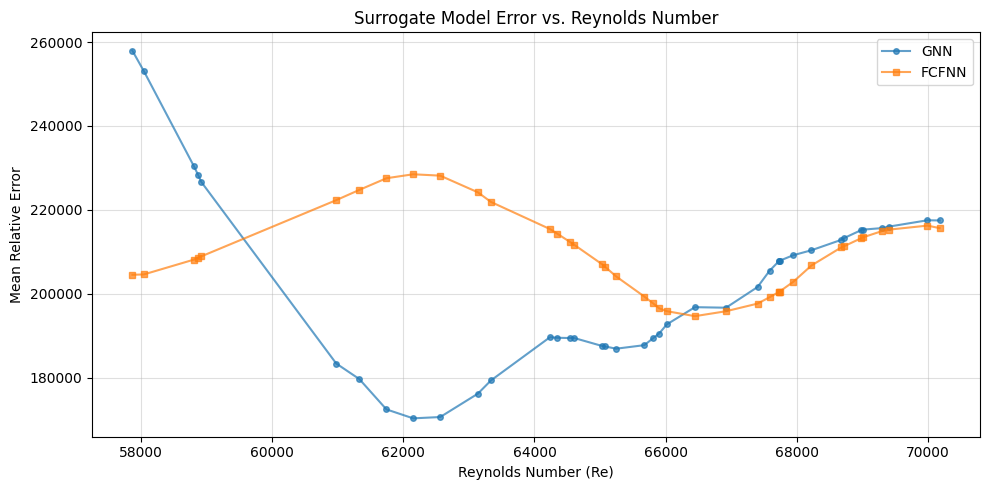

GNN   — mean error: 201875.9531, correlation with Re: -0.071
FCFNN — mean error: 209553.0469, correlation with Re: -0.246


In [26]:
#YOUR CODE HERE
# Evaluate both models on each simulation in the evaluation set
# and plot Re vs mean relative error

eval_re     = []
gnn_err  = []
fcfnn_err = []

print("Evaluating models over evaluation set:")
for sim_i, global_idx in enumerate(eval_idx):
    U_val    = float(data_tensor[global_idx, 2, 5])
    Re_val   = reynolds(U_val)
    actual   = data_tensor[global_idx, :, 3:6]

    gnn_pred   = predict_fields(U_val, "GNN")[:, 3:6]
    fcfnn_pred = predict_fields(U_val, "FCFNN")[:, 3:6]

    gnn_rel   = np.mean(np.abs(gnn_pred   - actual) / (np.abs(actual) + 1e-8))
    fcfnn_rel = np.mean(np.abs(fcfnn_pred - actual) / (np.abs(actual) + 1e-8))

    eval_re.append(Re_val)
    gnn_err.append(gnn_rel)
    fcfnn_err.append(fcfnn_rel)

    if (sim_i + 1) % 5 == 0:
        print(f"  {sim_i+1}/{len(eval_idx)} done")

eval_re      = np.array(eval_re)
gnn_err   = np.array(gnn_err)
fcfnn_err = np.array(fcfnn_err)

sort_idx = np.argsort(eval_re)
eval_re_s    = eval_re[sort_idx]
gnn_err_s    = gnn_err[sort_idx]
fcfnn_err_s  = fcfnn_err[sort_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(eval_re_s, gnn_err_s,   'o-', label='GNN',   alpha=0.7, markersize=4)
ax.plot(eval_re_s, fcfnn_err_s, 's-', label='FCFNN', alpha=0.7, markersize=4)
ax.set_xlabel("Reynolds Number (Re)")
ax.set_ylabel("Mean Relative Error")
ax.set_title("Surrogate Model Error vs. Reynolds Number")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"GNN   — mean error: {gnn_err.mean():.4f}, correlation with Re: {np.corrcoef(eval_re, gnn_err)[0,1]:.3f}")
print(f"FCFNN — mean error: {fcfnn_err.mean():.4f}, correlation with Re: {np.corrcoef(eval_re, fcfnn_err)[0,1]:.3f}")

Was your initial guess about the relationship between Re and the model's accuracy correct?

<font color=skyblue>**(Answer here)**</font>

The initial guess was generally incorrect, it would seem. The Re range here in the eval set also appears to be very narrow and high already, roughly within Re = [58000, 70000], so we don't get a very good understanding of how the data evolves from low Re to high Re at a larger scale.

Instead of a direct correlation we observe the GNN demonstrates U-shaped error progression, where the error is very high at low Re, dips severely towards Re=62000, and more gradually rises again until Re=70000. An argument I might give for why we observe this is due to the density of data available. Observe below ~Re=61000 the data is much more sparse than it is above, with 5 data points spanning an Re range of 3000 with wide gaps between clusters of data points. This could mean the model is much worse trained at approximating this data, producing the large error observed. After Re=61000, there are more data points that are more evenly distributed for the model to have trained off of and so in the evaluation the model performs better. We observe after Re=62000 the direct correlation we might expect, where as Re increases the error does as well.

On the FCFNN front, the performance vs Re is even less understandable. I'm unsure how to explain the apparently low error at low Re that then increases as the data becomes more available before decreasing and increasing again towards even higher Re. It may be of note that the two models appear to agree towards very high Re in that both show the direct correlation we expect within similar Re ranges above Re=66000. I'd like to again infer it may be due to variation in training set data for each model to learn from, and that perhaps there was less low Re data for the FCFNN than the GNN, resulting in the kind of unpredictable behavior observed.

There is also the possibility that our initial assumption was simply wrong, and that the relation of model performance with Re is different/more complex than I initially predicted.

### <span style="color:LightGreen">Question 10: Possible improvements (optional) </span>
What enhancements or modifications would you suggest for these surrogate models?

Is there another technique that you think will work better? feel free to test it down below.

We observed a fairly decent accuracy of our approximation, which was good! We found how machine learning methods like GNNs and FCFNNs can vastly improve performance times over traditional CFD simulations and approximate those models with minimal/minimizable error. Some improvements could be additional training across broader ranges of Re and specifically trying to ensure that the eval/training set split has training data that evenly covers ALL Re ranges. With such a measure in place, the model would have adequate training data for many ranges of Re, and we might observe the correlation we initially predicted.

## <span style="color:Orange">Acknowledgements</span>

* Initial version: Abdulaziz Alshohail with some guidance from Mark Neubauer

© Copyright 2025